In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
#read in data
popular = pd.read_csv('high_popularity_spotify_data.csv')
unpopular = pd.read_csv('low_popularity_spotify_data.csv')

In [2]:
#combine the two datasets into one
df = pd.concat([popular, unpopular], axis=0, ignore_index=True)
df.head(10)

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.1220,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,0.000000,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.1170,0.438,Billie Eilish,4.0,0.0358,...,0.060800,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.1590,0.372,Gracie Abrams,4.0,0.0368,...,0.000000,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.3040,0.786,Sabrina Carpenter,4.0,0.0634,...,0.000000,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.3550,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,0.000000,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
5,0.582,116.712,0.700,pop,-5.960,0.0881,0.785,Chappell Roan,4.0,0.0356,...,0.000000,1WAjjRMfZjEXtB0lQrAw6Q,0.0,11.0,218424.0,0.0502,0WbMK4wrZ1wFSty9F7FCgu,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
6,0.561,150.069,0.669,pop,-6.538,0.0954,0.841,Addison Rae,4.0,0.0411,...,0.009620,0XA403JTounqFh2owquBXu,1.0,10.0,169698.0,0.4950,6MzofobZt2dm0Kf1hTThFz,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
7,0.247,148.101,0.467,pop,-12.002,0.1700,0.126,Billie Eilish,4.0,0.0431,...,0.000271,7aJuG4TFXa2hmE4z1yxc3n,0.0,6.0,261467.0,0.6120,3QaPy1KgI7nu9FJEQUgn6h,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
8,0.416,94.926,0.492,pop,-10.439,0.2030,0.297,Gigi Perez,4.0,0.0254,...,0.000086,4DWrYvfGXRE8ko5ZxlIpit,1.0,11.0,211979.0,0.6860,0UYnhUfnUj5adChuAXvLUB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
9,0.722,119.973,0.769,pop,-5.485,0.1110,0.570,"The Weeknd, Playboi Carti",4.0,0.0507,...,0.000003,2IRxVVqbSbqHJo8Zx50LYn,0.0,11.0,256000.0,0.0584,1Es7AUAhQvapIcoh3qMKDL,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


            energy        tempo  danceability     loudness     liveness  \
count  4830.000000  4830.000000   4830.000000  4830.000000  4830.000000   
mean      0.586691   118.269293      0.622311    -9.281627     0.167613   
std       0.246263    28.512615      0.187706     7.129396     0.124429   
min       0.000202    48.232000      0.058900   -48.069000     0.021000   
25%       0.442250    96.063000      0.525000   -10.297750     0.095400   
50%       0.633000   118.059500      0.653000    -7.191000     0.118000   
75%       0.777000   136.723500      0.758000    -5.336750     0.195000   
max       0.998000   241.426000      0.979000     1.318000     0.979000   

           valence  time_signature  speechiness  track_popularity  \
count  4830.000000     4830.000000  4830.000000       4831.000000   
mean      0.481930        3.936646     0.101738         54.761126   
std       0.258036        0.409712     0.101032         19.828573   
min       0.029600        1.000000     0.021900 

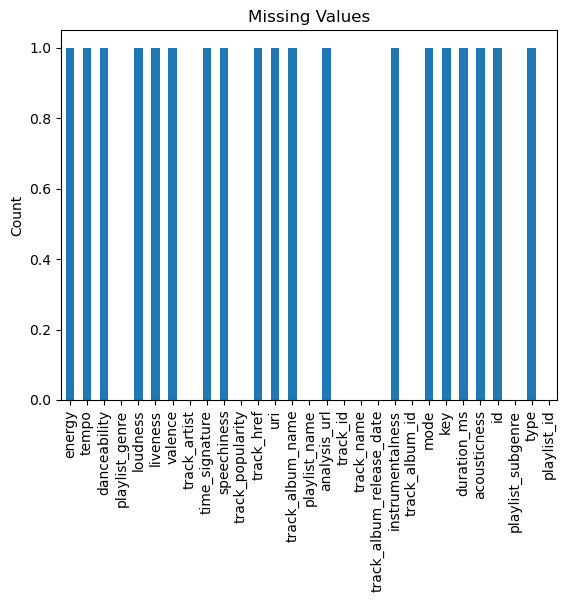

In [3]:
#general look at data
print(df.describe())
print(df.isnull().sum())

#visualize all missing values
missing = df.isnull().sum()
missing.plot(kind='bar')
plt.title('Missing Values')
plt.ylabel('Count')
plt.show()

In [4]:
#pick only the selected features + response variable
df_model = df[['track_popularity', 'loudness', 'energy', 'danceability', 'instrumentalness', 'acousticness']]
#drop rows with missing values (very few)
df_model = df_model.dropna()

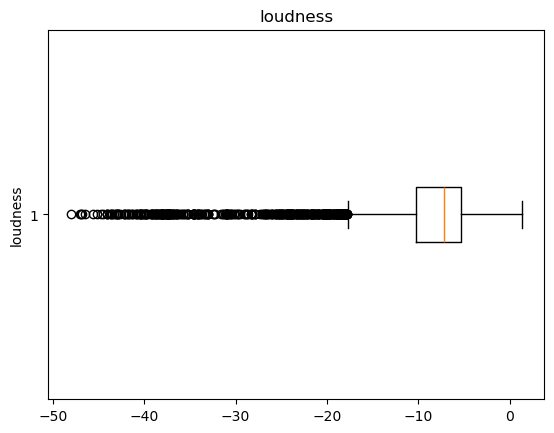

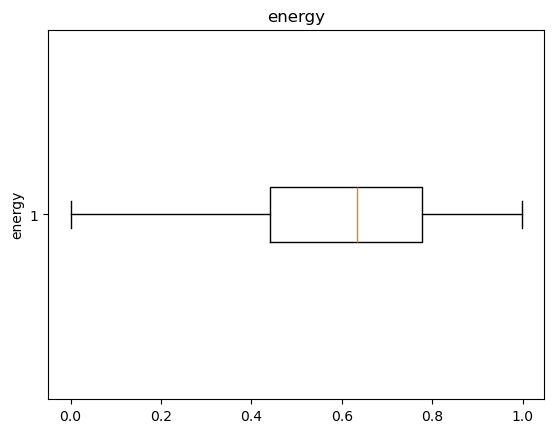

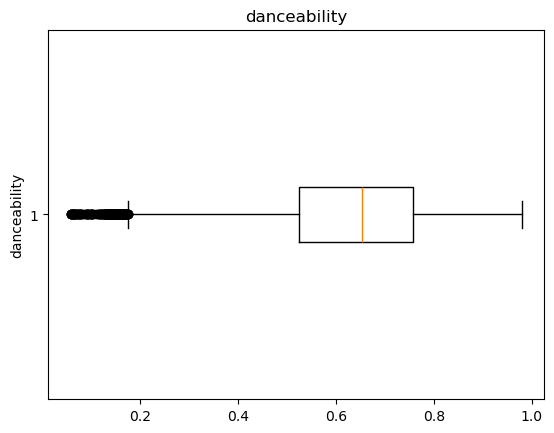

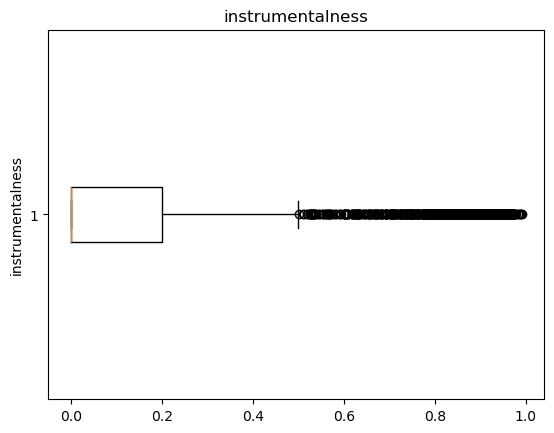

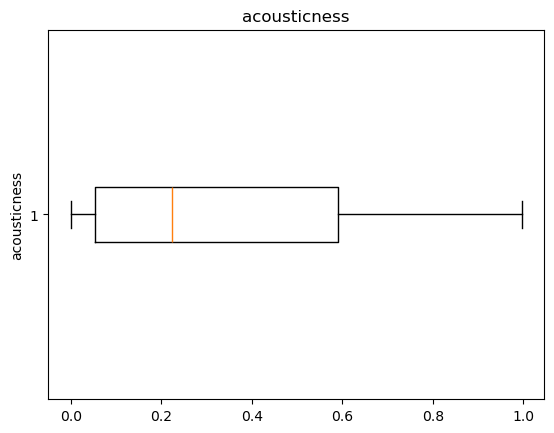

In [5]:
features = ['loudness', 'energy', 'danceability', 'instrumentalness', 'acousticness']
#look at chosen features for outliers
for col in features:
    plt.figure()
    plt.boxplot(df_model[col], vert=False)
    plt.title(col)
    plt.ylabel(col)
    plt.show()

We will not remove any outliers because they represent real variation in songs rather than error in data collection. 

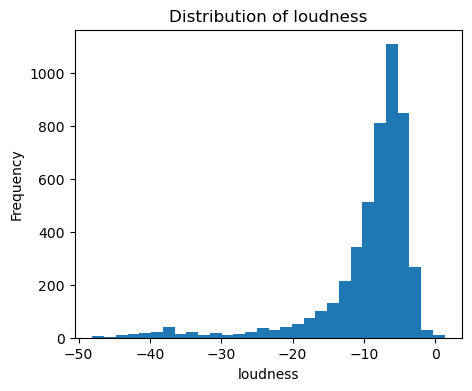

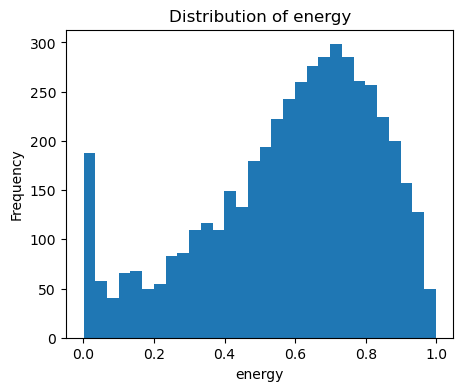

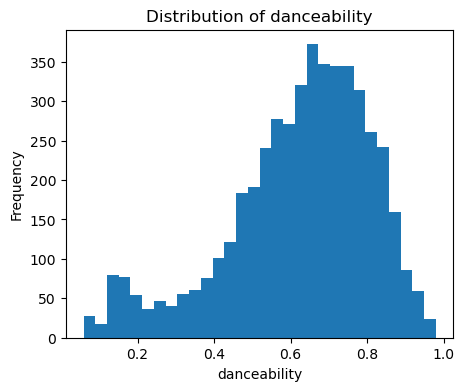

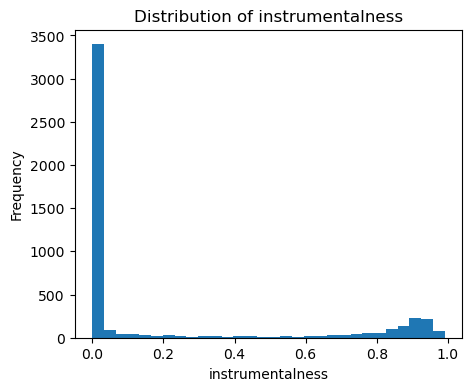

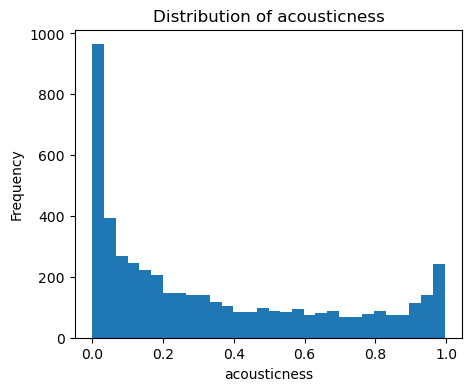

In [6]:
#look at distributions
for col in features:
    plt.figure(figsize=(5,4))
    plt.hist(df_model[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

We will not transform any data because the skewness observed in some of the variables is due to real world variation and should be represented. 

          loudness       energy  danceability  instrumentalness  acousticness
count  4830.000000  4830.000000   4830.000000       4830.000000   4830.000000
mean     -9.281627     0.586691      0.622311          0.201053      0.341217
std       7.129396     0.246263      0.187706          0.351918      0.325382
min     -48.069000     0.000202      0.058900          0.000000      0.000004
25%     -10.297750     0.442250      0.525000          0.000000      0.052925
50%      -7.191000     0.633000      0.653000          0.000091      0.224500
75%      -5.336750     0.777000      0.758000          0.200500      0.590000
max       1.318000     0.998000      0.979000          0.991000      0.996000


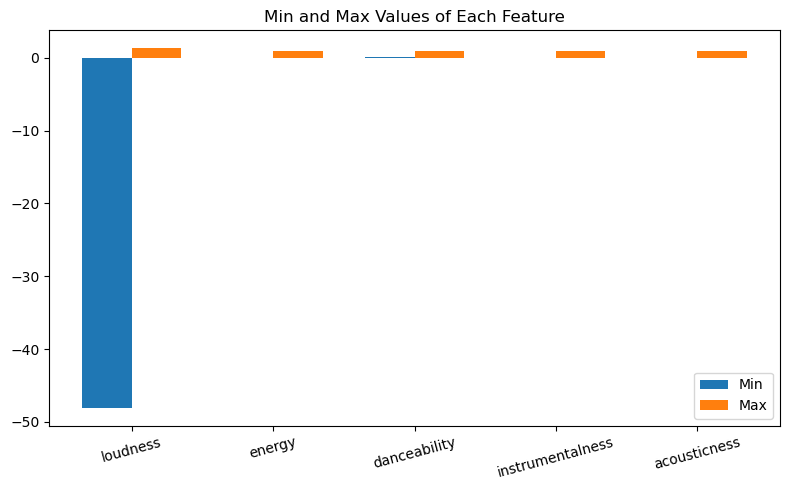

In [7]:
#check the scale of each feature
df_model = df[features]
print(df_model.describe())

#need to visualize min/max of each feature.
mins = df_model[features].min()
maxs = df_model[features].max()
x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, mins, width, label='Min')
plt.bar(x + width/2, maxs, width, label='Max')
plt.xticks(x, features, rotation=15)
plt.title('Min and Max Values of Each Feature')
plt.legend()
plt.tight_layout()
plt.show()

The features have different ranges (aka loudness is negative and spans a large range while others are between 0 and 1). 

Scaled feature statistics:
           loudness        energy  danceability  instrumentalness  \
count  4.830000e+03  4.830000e+03  4.830000e+03      4.830000e+03   
mean  -9.415059e-17  4.707530e-17  2.353765e-17      9.415059e-17   
std    1.000104e+00  1.000104e+00  1.000104e+00      1.000104e+00   
min   -5.441049e+00 -2.381806e+00 -3.001877e+00     -5.713641e-01   
25%   -1.425406e-01 -5.865935e-01 -5.184766e-01     -5.713641e-01   
50%    2.932707e-01  1.880664e-01  1.635127e-01     -5.711046e-01   
75%    5.533828e-01  7.728687e-01  7.229571e-01     -1.570342e-03   
max    1.486904e+00  1.670378e+00  1.900454e+00      2.244923e+00   

       acousticness  
count  4.830000e+03  
mean   8.238177e-17  
std    1.000104e+00  
min   -1.048763e+00  
25%   -8.861024e-01  
50%   -3.587446e-01  
75%    7.646666e-01  
max    2.012560e+00  


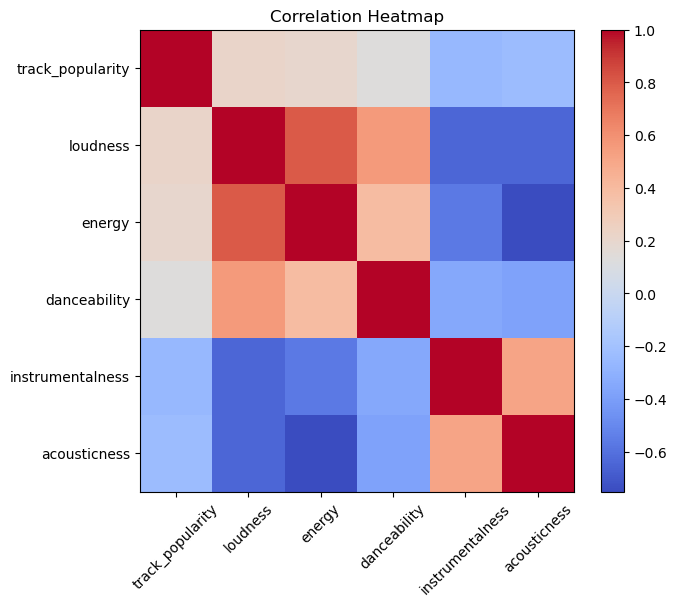

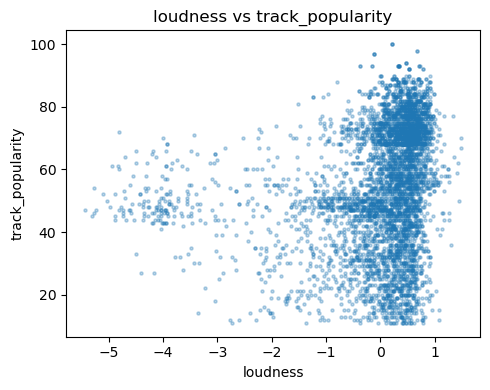

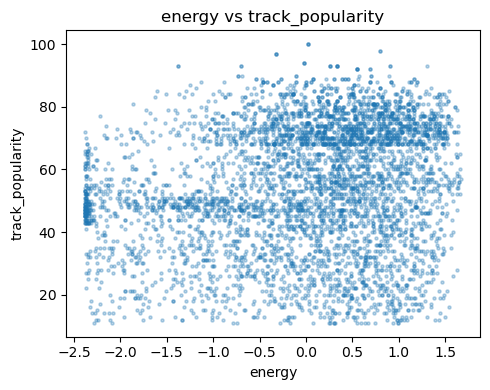

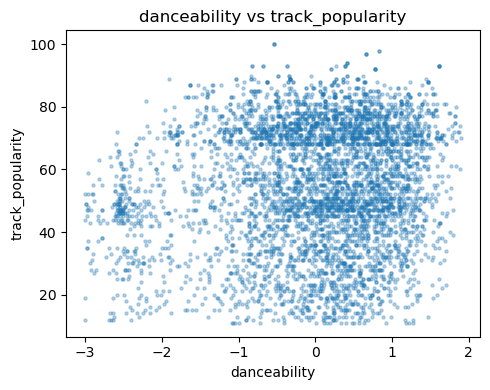

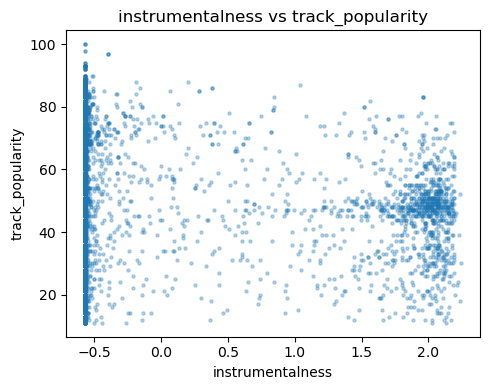

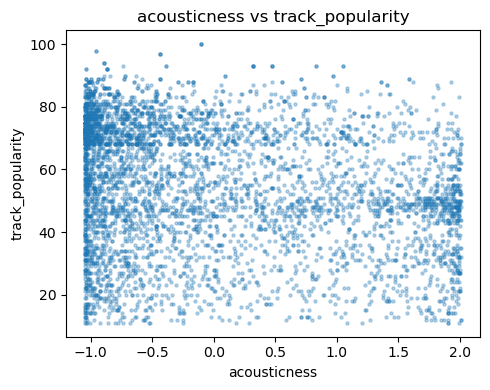

In [14]:
df_model = df[['track_popularity', 'loudness', 'energy', 'danceability', 'instrumentalness', 'acousticness']]
features = ['loudness', 'energy', 'danceability', 'instrumentalness', 'acousticness']

scaler = StandardScaler()
df_model.loc[:, features] = scaler.fit_transform(df_model[features])
print('Scaled feature statistics:')
print(df_model[features].describe())

plt.figure(figsize=(7, 6))
corr = df_model[['track_popularity'] + features].corr()
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()

#make scatterplots
for col in features:
    plt.figure(figsize=(5, 4))
    plt.scatter(df_model[col], df_model['track_popularity'], alpha=0.3, s=5)
    plt.xlabel(col)
    plt.ylabel('track_popularity')
    plt.title(f'{col} vs track_popularity')
    plt.tight_layout()
    plt.show()